In [1]:
# Cell 1: imports & paths

import os
from glob import glob

import numpy as np
import pandas as pd
import xarray as xr

#BASE_ERA5 = "/home/luty8/data10/GoM_data/processed_data/ERA5_small"

EVENT_ATTR_NC = "/Users/luty8/MHW_Project/data/core/oisst/mhw_basin_detrended_1982-2024_xmhw.nc"
LABEL_NC      = "/Users/luty8/MHW_Project/data/core/eof_kmeans/detrend_labels_K4_1982-2024.nc"

OUT_DIR = "/Users/luty8/MHW_Project/data/interim/time_composite_peakalign"
os.makedirs(OUT_DIR, exist_ok=True)

#print("BASE_ERA5     :", BASE_ERA5)
print("EVENT_ATTR_NC :", EVENT_ATTR_NC)
print("LABEL_NC      :", LABEL_NC)
print("OUT_DIR       :", OUT_DIR)


EVENT_ATTR_NC : /Users/luty8/MHW_Project/data/core/oisst/mhw_basin_detrended_1982-2024_xmhw.nc
LABEL_NC      : /Users/luty8/MHW_Project/data/core/eof_kmeans/detrend_labels_K4_1982-2024.nc
OUT_DIR       : /Users/luty8/MHW_Project/data/interim/time_composite_peakalign


In [2]:
# Cell 2: config

FIELD_KIND = "resid"   # 你的 ERA5_small 文件名里就是 resid

LAG_PRE  = 30          # peak 前 30 天
LAG_POST = 30          # peak 后 30 天

TAG = f"peakalign_lag{LAG_PRE:02d}_{LAG_POST:02d}_{FIELD_KIND}"
print("TAG:", TAG)

TAG: peakalign_lag30_30_resid


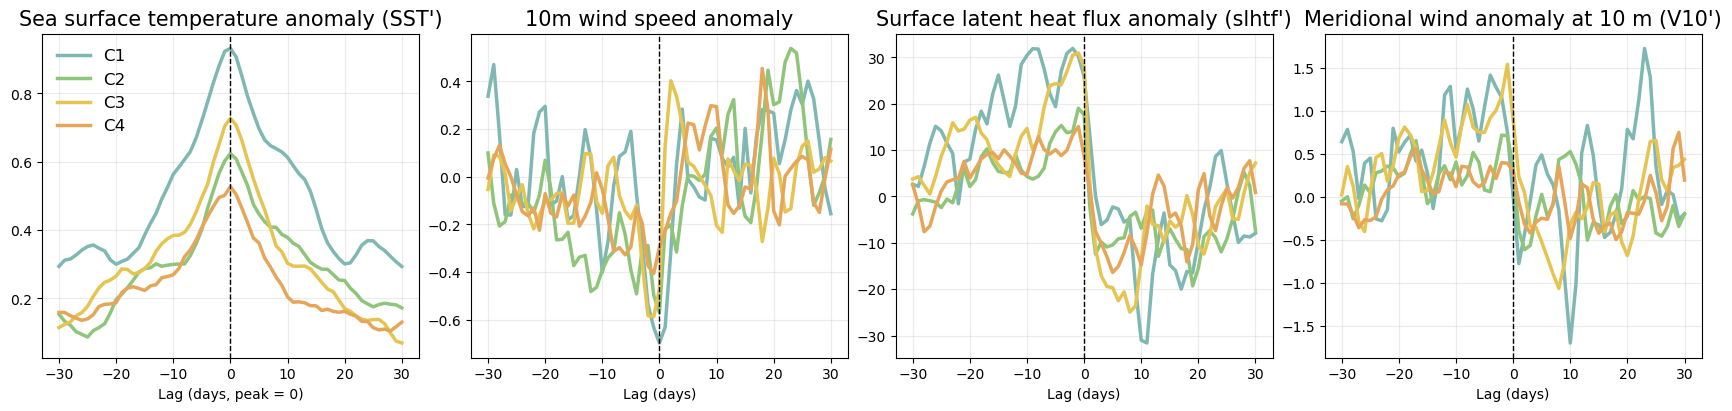

In [3]:
import matplotlib.pyplot as plt
import xarray as xr
import os

selected = ["sst", "wind_speed", "avg_slhtf", "v10"]

# Full names for display
var_fullnames = {
    "sst": "Sea surface temperature anomaly (SST')",
    "wind_speed": "10m wind speed anomaly",
    "avg_slhtf": "Surface latent heat flux anomaly (slhtf')",
    "v10": "Meridional wind anomaly at 10 m (V10')",
}

cluster_colors = [
    "#7fb8b3",  # C1
    "#8fc57a",  # C2
    "#e6c451",  # C3
    "#e6a65a",  # C4
]

fig, axes = plt.subplots(
    1, 4,
    figsize=(17, 4),
    sharex=True,
    constrained_layout=True,
)

for ax, token in zip(axes, selected):
    fn = os.path.join(OUT_DIR, f"ERA5_{token}_{TAG}_clusterLag_ts.nc")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"Missing: {fn}")

    ds = xr.open_dataset(fn)
    ts = ds[f"{token}_{FIELD_KIND}_ts"]

    for cl in ts["cluster"].values:
        color = cluster_colors[int(cl)]
        ax.plot(
            ts["lag"], ts.sel(cluster=cl),
            linewidth=2.5,
            color=color,
            label=f"C{int(cl)+1}"
        )

    ax.axvline(0, color="k", linestyle="--", linewidth=1.0)

    # === 使用全称作为标题 ===
    ax.set_title(var_fullnames[token], fontsize=15)

    ax.grid(True, alpha=0.25)

axes[0].set_xlabel("Lag (days, peak = 0)")
for ax in axes[1:]:
    ax.set_xlabel("Lag (days)")

# Put legend inside the first panel
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(
    handles, labels,
    loc="upper left",
    frameon=False,
    fontsize=12,
)

#fig.suptitle(f"Peak-aligned cluster mean (area mean) — {TAG}", fontsize=20)
plt.show()


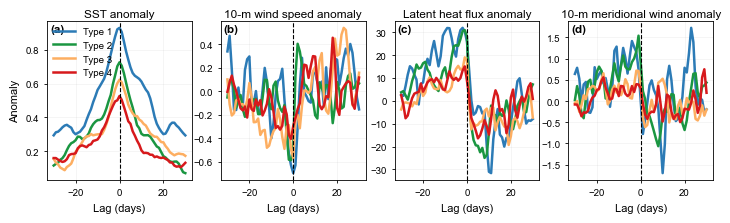

In [4]:
import os
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------------------------------
# Journal-style settings
# -------------------------------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 8.5,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.3,
    "ytick.major.size": 2.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

selected = ["sst", "wind_speed", "avg_slhtf", "v10"]

# shorter journal-style titles
var_titles = {
    "sst": "SST anomaly",
    "wind_speed": "10-m wind speed anomaly",
    "avg_slhtf": "Latent heat flux anomaly",
    "v10": "10-m meridional wind anomaly",
}

# swapped Type colors kept consistent with your earlier figures
type_colors = [
    "#2c7bb6",  # Type 1
    "#1a9641",  # Type 2
    "#fdae61",  # Type 3
    "#d7191c",  # Type 4
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

fig, axes = plt.subplots(
    1, 4,
    figsize=(7.2, 2.35),
    sharex=True,
    constrained_layout=False,
)

for i, (ax, token) in enumerate(zip(axes, selected)):
    fn = os.path.join(OUT_DIR, f"ERA5_{token}_{TAG}_clusterLag_ts.nc")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"Missing: {fn}")

    ds = xr.open_dataset(fn)
    ts = ds[f"{token}_{FIELD_KIND}_ts"]

    # swap Type 2 / 3
    ts = ts.isel(cluster=[0, 2, 1, 3])

    for k in range(4):
        ax.plot(
            ts["lag"],
            ts.isel(cluster=k),
            linewidth=1.8,
            color=type_colors[k],
            label=f"Type {k+1}"
        )

    ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
    ax.grid(True, alpha=0.22, linewidth=0.4)
    ax.set_title(var_titles[token], fontsize=8.5, pad=2.5)

    ax.text(
        0.02, 0.98, panel_labels[i],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=8.5,
        fontweight="bold"
    )

    # cleaner x label only at bottom line; since 1 row, all okay
    ax.set_xlabel("Lag (days)")

# y-label only on first panel usually cleaner
axes[0].set_ylabel("Anomaly")
axes[0].legend(
    loc="upper left",
    frameon=False,
    handlelength=2.2,
    borderaxespad=0.25
)

fig.subplots_adjust(
    left=0.07, right=0.995,
    bottom=0.20, top=0.88,
    wspace=0.2
)

plt.show()



In [5]:
DPI = 600
def save_fig(fig, name_base, outdir="."):
    pdf_path = f"{outdir}/{name_base}.pdf"
    png_path = f"{outdir}/{name_base}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=DPI, bbox_inches="tight")
    print(f"Saved: {pdf_path}")
    print(f"Saved: {png_path}")

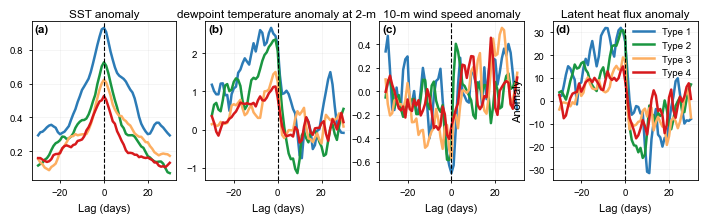

Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig8_timelag_ERA5.pdf
Saved: /Users/luty8/Documents/TAMU/agu25/fig/Fig8_timelag_ERA5.png


In [7]:
import os
import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------------------------------
# Journal-style settings
# -------------------------------------------------
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 8,
    "axes.titlesize": 8.5,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.3,
    "ytick.major.size": 2.3,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

selected = ["sst", "d2m","wind_speed", "avg_slhtf", ]

# shorter journal-style titles
var_titles = {
    "sst": "SST anomaly",
    "d2m": "dewpoint temperature anomaly at 2-m ",
    "wind_speed": "10-m wind speed anomaly",
    "avg_slhtf": "Latent heat flux anomaly",
    
}

# swapped Type colors kept consistent with your earlier figures
type_colors = [
    "#2c7bb6",  # Type 1
    "#1a9641",  # Type 2
    "#fdae61",  # Type 3
    "#d7191c",  # Type 4
]

panel_labels = ["(a)", "(b)", "(c)", "(d)"]

fig, axes = plt.subplots(
    1, 4,
    figsize=(7.2, 2.35),
    sharex=True,
    constrained_layout=False,
)

for i, (ax, token) in enumerate(zip(axes, selected)):
    fn = os.path.join(OUT_DIR, f"ERA5_{token}_{TAG}_clusterLag_ts.nc")
    if not os.path.exists(fn):
        raise FileNotFoundError(f"Missing: {fn}")

    ds = xr.open_dataset(fn)
    ts = ds[f"{token}_{FIELD_KIND}_ts"]

    # swap Type 2 / 3
    ts = ts.isel(cluster=[0, 2, 1, 3])

    for k in range(4):
        ax.plot(
            ts["lag"],
            ts.isel(cluster=k),
            linewidth=1.8,
            color=type_colors[k],
            label=f"Type {k+1}"
        )

    ax.axvline(0, color="k", linestyle="--", linewidth=0.8)
    ax.grid(True, alpha=0.22, linewidth=0.4)
    ax.set_title(var_titles[token], fontsize=8.5, pad=2.5)

    ax.text(
        0.02, 0.98, panel_labels[i],
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=8.5,
        fontweight="bold"
    )

    # cleaner x label only at bottom line; since 1 row, all okay
    ax.set_xlabel("Lag (days)")

# y-label only on first panel usually cleaner
axes[3].set_ylabel("Anomaly")
axes[3].legend(
    loc="upper right",
    frameon=False,
    handlelength=2.2,
    borderaxespad=0.25
)

fig.subplots_adjust(
    left=0.07, right=0.995,
    bottom=0.20, top=0.88,
    wspace=0.2
)

plt.show()

save_fig(fig, "Fig8_timelag_ERA5", outdir="/Users/luty8/Documents/TAMU/agu25/fig")